condition
IFNb_4h        3
IFNg_4h        3
LPS+IFNg_4h    3
Mono           3
Naive          3
Name: sample, dtype: int64


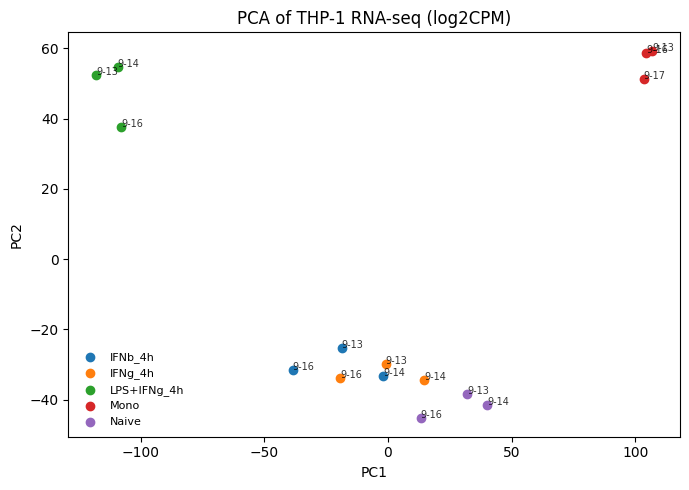

Marker genes present: 15


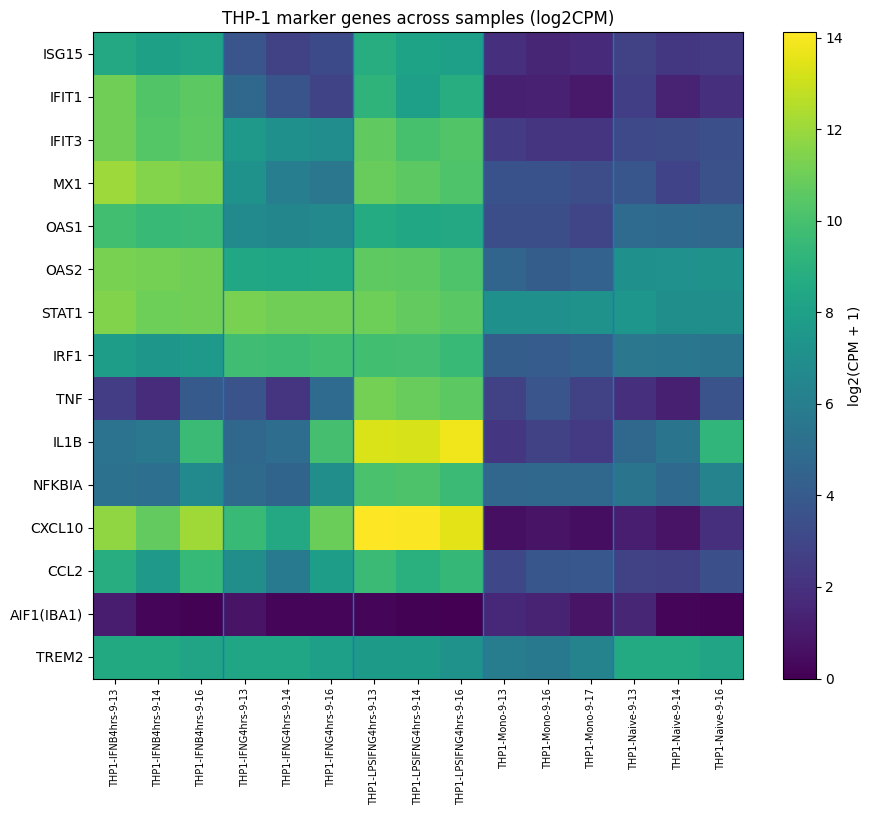

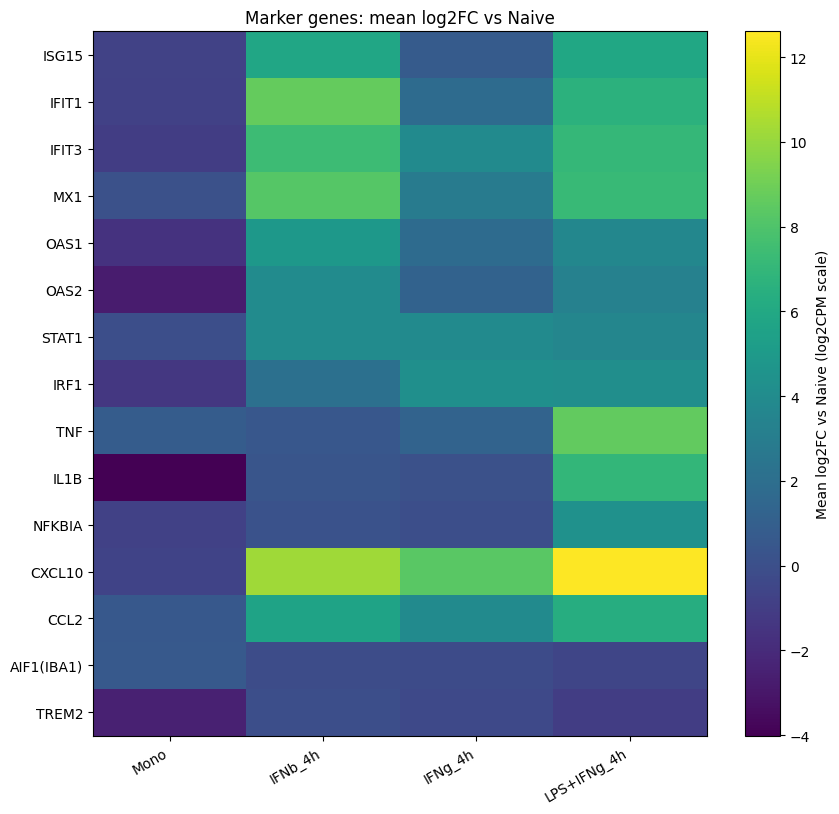

Saved figures:
- THP1_RNAseq_PCA_log2CPM.png
- THP1_marker_heatmap_log2CPM.png
- THP1_marker_log2FC_vs_Naive.png


In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) Load counts
# =========================
path = r"D:\rna-seq\THP1\count_matrix_all.txt"
counts = pd.read_csv(path, sep="\t")

# Expect first col name is "Geneid"
gene_col = counts.columns[0]
counts = counts.set_index(gene_col)

# Make numeric
counts = counts.apply(pd.to_numeric, errors="coerce").fillna(0)

# Drop genes with all zeros (optional but speeds up)
counts = counts.loc[counts.sum(axis=1) > 0]

# =========================
# 1) Sample metadata from column names
# =========================
def parse_condition(sample: str) -> str:
    s = sample.upper()
    if "LPSIFNG4HRS" in s:
        return "LPS+IFNg_4h"
    if "IFNB4HRS" in s:
        return "IFNb_4h"
    if "IFNG4HRS" in s:
        return "IFNg_4h"
    if "MONO" in s:
        return "Mono"
    if "NAIVE" in s:
        return "Naive"
    return "Other"

def parse_rep(sample: str) -> str:
    # last token like 9-13 / 9-14 / 9-16
    toks = sample.split("-")
    if len(toks) >= 2:
        return "-".join(toks[-2:])  # e.g., 9-13
    return sample

meta = pd.DataFrame({"sample": counts.columns})
meta["condition"] = meta["sample"].apply(parse_condition)
meta["rep"] = meta["sample"].apply(parse_rep)

print(meta.groupby("condition")["sample"].count())

# Order samples by condition then rep
sample_order = meta.sort_values(["condition", "rep"])["sample"].tolist()

# =========================
# 2) CPM + log2 transform
# =========================
lib = counts.sum(axis=0)
cpm = counts.div(lib, axis=1) * 1e6
log2cpm = np.log2(cpm + 1)

# =========================
# 3) PCA (simple SVD on centered genes)
#    No sklearn needed.
# =========================
X = log2cpm.T  # samples x genes
# center genes
Xc = X - X.mean(axis=0)

# SVD
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
pc_scores = U[:, :2] * S[:2]  # samples x 2

pca_df = meta.set_index("sample").loc[X.index].copy()
pca_df["PC1"] = pc_scores[:, 0]
pca_df["PC2"] = pc_scores[:, 1]

# Plot PCA
plt.figure(figsize=(7, 5))
for cond, sub in pca_df.groupby("condition"):
    plt.scatter(sub["PC1"], sub["PC2"], label=cond)
for sname, row in pca_df.iterrows():
    plt.text(row["PC1"], row["PC2"], s=row["rep"], fontsize=7, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of THP-1 RNA-seq (log2CPM)")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig("THP1_RNAseq_PCA_log2CPM.pdf", dpi=300)
plt.show()

# =========================
# 4) Marker gene heatmap
#    Using Ensembl IDs (with versions). We'll strip version.
# =========================
# Helper: strip ".version"
ensg_noversion = pd.Index([g.split(".")[0] for g in log2cpm.index], name="Geneid")
log2cpm_nv = log2cpm.copy()
log2cpm_nv.index = ensg_noversion

# Minimal marker set (Ensembl IDs for human; edit if needed)
# NOTE: IDs below are commonly used; if any are missing in your file, they will be skipped.
markers = {
    # IFN / ISGs
    "ISG15": "ENSG00000187608",
    "IFIT1": "ENSG00000185745",
    "IFIT3": "ENSG00000119917",
    "MX1":   "ENSG00000157601",
    "OAS1":  "ENSG00000089127",
    "OAS2":  "ENSG00000111331",
    "STAT1": "ENSG00000115415",
    "IRF1":  "ENSG00000125347",
    # inflammatory
    "TNF":   "ENSG00000232810",
    "IL1B":  "ENSG00000125538",
    "NFKBIA":"ENSG00000100906",
    "CXCL10":"ENSG00000169245",
    "CCL2":  "ENSG00000108691",
    # macrophage-ish
    "AIF1(IBA1)": "ENSG00000160593",
    "TREM2": "ENSG00000095970",
}

present = [(sym, ensg) for sym, ensg in markers.items() if ensg in log2cpm_nv.index]
missing = [(sym, ensg) for sym, ensg in markers.items() if ensg not in log2cpm_nv.index]
print(f"Marker genes present: {len(present)}")
if missing:
    print("Missing markers (OK):")
    for sym, ensg in missing:
        print(f"  {sym}: {ensg}")

if len(present) >= 3:
    heat_rows = [ensg for _, ensg in present]
    heat = log2cpm_nv.loc[heat_rows, sample_order].copy()
    row_labels = [sym for sym, _ in present]

    plt.figure(figsize=(0.35 * len(sample_order) + 4, 0.35 * len(row_labels) + 3))
    im = plt.imshow(heat.values, aspect="auto")
    plt.colorbar(im, label="log2(CPM + 1)")
    plt.yticks(range(len(row_labels)), row_labels)
    plt.xticks(range(len(sample_order)), sample_order, rotation=90, fontsize=7)

    # vertical lines between conditions
    conds = meta.set_index("sample").loc[sample_order, "condition"].tolist()
    for i in range(1, len(sample_order)):
        if conds[i] != conds[i-1]:
            plt.axvline(i - 0.5, linewidth=1)

    plt.title("THP-1 marker genes across samples (log2CPM)")
    plt.tight_layout()
    plt.savefig("THP1_marker_heatmap_log2CPM.pdf", dpi=300)
    plt.show()

# =========================
# 5) Mean log2FC vs Naive (per condition) for markers
# =========================
if "Naive" in set(meta["condition"]):
    naive_samples = meta.loc[meta["condition"] == "Naive", "sample"].tolist()
    naive_mean = log2cpm_nv[naive_samples].mean(axis=1)

    log2fc = log2cpm_nv.sub(naive_mean, axis=0)

    # summarize for marker genes
    if len(present) >= 3:
        marker_ensg = [ensg for _, ensg in present]
        fc_mat = []
        conds_sorted = [c for c in ["Mono", "IFNb_4h", "IFNg_4h", "LPS+IFNg_4h"] if c in set(meta["condition"])]

        for cond in conds_sorted:
            samples = meta.loc[meta["condition"] == cond, "sample"].tolist()
            fc_mat.append(log2fc.loc[marker_ensg, samples].mean(axis=1).values)

        fc_mat = np.vstack(fc_mat).T  # genes x conditions
        plt.figure(figsize=(1.2 * len(conds_sorted) + 4, 0.35 * len(marker_ensg) + 3))
        im = plt.imshow(fc_mat, aspect="auto")
        plt.colorbar(im, label="Mean log2FC vs Naive (log2CPM scale)")
        plt.yticks(range(len(marker_ensg)), [sym for sym, _ in present])
        plt.xticks(range(len(conds_sorted)), conds_sorted, rotation=30, ha="right")
        plt.title("Marker genes: mean log2FC vs Naive")
        plt.tight_layout()
        plt.savefig("THP1_marker_log2FC_vs_Naive.pdf", dpi=300)
        plt.show()

print("Saved figures:\n- THP1_RNAseq_PCA_log2CPM.png\n- THP1_marker_heatmap_log2CPM.png\n- THP1_marker_log2FC_vs_Naive.png")
